In [2]:
from prophet import Prophet
from google.cloud import bigquery
from google.oauth2 import service_account
import pandas as pd

In [5]:
credentials = service_account.Credentials.from_service_account_file(
    r"E:\retail-pulse-project\Credential\retail-pulse-496303-ca384c444638.json"
)

client = bigquery.Client(
    credentials=credentials,
    project="retail-pulse-496303"
)

print("Connected to BigQuery!")

Connected to BigQuery!


In [10]:
sales_ts = client.query("""
SELECT
    DATE(order_date) AS ds,
    SUM(sales) AS y
FROM raw_data.fact_sales
GROUP BY ds
ORDER BY ds
""").to_dataframe()

sales_ts.head()

,ds,y
0,2011-01-01,808
1,2011-01-02,314
2,2011-01-03,4502
3,2011-01-04,2809
4,2011-01-05,3664


In [11]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(sales_ts)

13:23:18 - cmdstanpy - INFO - Chain [1] start processing
13:23:19 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
future = model.make_future_dataframe(periods=90)

forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2011-01-01,5204.842328,-2436.266012,8494.595169,5204.842328,5204.842328,-2241.517408,-2241.517408,-2241.517408,-2980.479727,-2980.479727,-2980.479727,738.962318,738.962318,738.962318,0.0,0.0,0.0,2963.324919
1,2011-01-02,5209.038653,-7580.667468,3543.763383,5209.038653,5209.038653,-7415.042114,-7415.042114,-7415.042114,-7786.517602,-7786.517602,-7786.517602,371.475488,371.475488,371.475488,0.0,0.0,0.0,-2206.003461
2,2011-01-03,5213.234979,1837.967912,12807.545364,5213.234979,5213.234979,2075.184004,2075.184004,2075.184004,2072.132702,2072.132702,2072.132702,3.051302,3.051302,3.051302,0.0,0.0,0.0,7288.418983
3,2011-01-04,5217.431304,1563.382218,12781.211328,5217.431304,5217.431304,1860.744899,1860.744899,1860.744899,2222.133426,2222.133426,2222.133426,-361.388526,-361.388526,-361.388526,0.0,0.0,0.0,7078.176204
4,2011-01-05,5221.627630,1020.937846,11882.207843,5221.627630,5221.627630,1025.183691,1025.183691,1025.183691,1742.202482,1742.202482,1742.202482,-717.018791,-717.018791,-717.018791,0.0,0.0,0.0,6246.811321


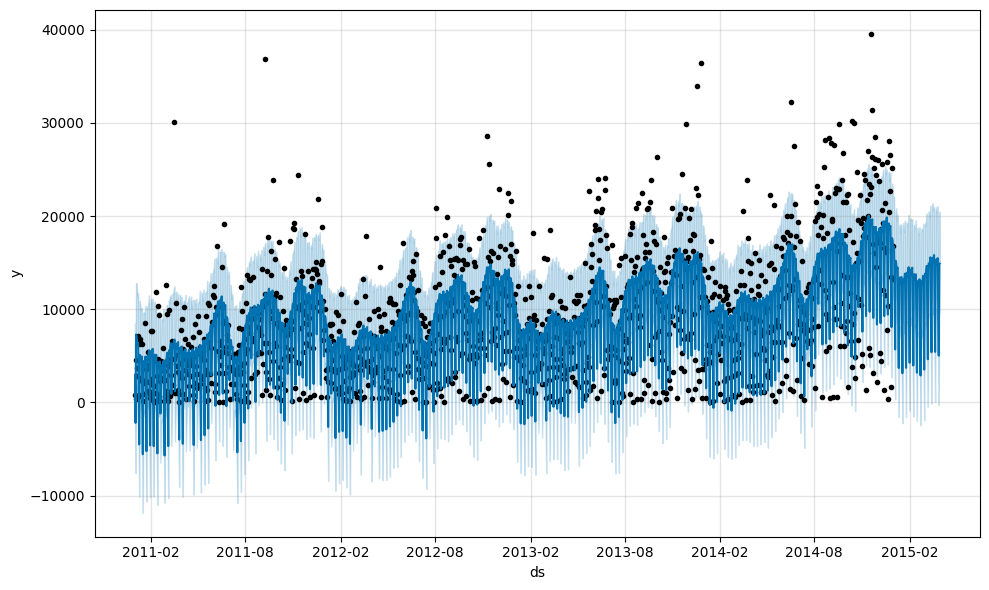

In [13]:
import matplotlib.pyplot as plt

fig = model.plot(forecast)
plt.show()

In [14]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv(
    "forecast.csv",
    index=False
)

print("Forecast CSV saved")

Forecast CSV saved


In [15]:
forecast_table = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

job = client.load_table_from_dataframe(
    forecast_table,
    "retail-pulse-496303.raw_data.sales_forecast"
)

job.result()

print("Forecast uploaded to BigQuery")

Forecast uploaded to BigQuery
